
# Africa coverage map

Locations from R7/R8/R9 overlaid on Natural Earth admin boundaries from scratch.


In [ ]:
import re
import unicodedata
from pathlib import Path

import geopandas as gpd
import matplotlib as mpl
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.patches import Patch

survey_country_map = {
    'ANG': 'Angola',
    'BEN': 'Benin',
    'BFO': 'Burkina Faso',
    'BOT': 'Botswana',
    'CAM': 'Cameroon',
    'CBZ': 'Congo',
    'CDI': "Cote d'Ivoire",
    'CVE': 'Cabo Verde',
    'ESW': 'eSwatini',
    'ETH': 'Ethiopia',
    'GAB': 'Gabon',
    'GAM': 'Gambia',
    'GHA': 'Ghana',
    'GUI': 'Guinea',
    'KEN': 'Kenya',
    'LES': 'Lesotho',
    'LIB': 'Liberia',
    'MAD': 'Madagascar',
    'MAU': 'Mauritius',
    'MLI': 'Mali',
    'MLW': 'Malawi',
    'MOR': 'Morocco',
    'MOZ': 'Mozambique',
    'MTA': 'Mauritania',
    'NAM': 'Namibia',
    'NGR': 'Niger',
    'NIG': 'Nigeria',
    'SAF': 'South Africa',
    'SEN': 'Senegal',
    'SEY': 'Seychelles',
    'SRL': 'Sierra Leone',
    'STP': 'Sao Tome and Principe',
    'SUD': 'Sudan',
    'SWZ': 'eSwatini',
    'TAN': 'Tanzania',
    'TOG': 'Togo',
    'TUN': 'Tunisia',
    'UGA': 'Uganda',
    'ZAM': 'Zambia',
    'ZIM': 'Zimbabwe',
}
country_aliases = {
    "eq. guinea": 'equatorial guinea',
    'dem. rep. congo': 'democratic republic of the congo',
    'central african rep.': 'central african republic',
    's. sudan': 'south sudan',
}

def make_country_key(name):
    if pd.isna(name):
        return pd.NA
    normalized = unicodedata.normalize('NFKD', str(name)).encode('ascii', 'ignore').decode('ascii')
    normalized = re.sub(r'\s+', ' ', normalized).strip().lower()
    return country_aliases.get(normalized, normalized)

def add_no_data_layer(ax, africa_gdf, data_country_keys):
    no_data = africa_gdf.loc[~africa_gdf['country_key'].isin(data_country_keys)].copy()
    if not no_data.empty:
        no_data.plot(
            ax=ax,
            facecolor='#f8fafc',
            edgecolor='#94a3b8',
            linewidth=0.5,
            hatch='///',
            zorder=1.5,
        )
    return no_data

# ----------------------------
# Data
# ----------------------------
csv_paths = [
    Path('/home/mila/e/echchabo/scratch/SDG6-Tracker/R7.csv'),
    Path('/home/mila/e/echchabo/scratch/SDG6-Tracker/R8.csv'),
    Path('/home/mila/e/echchabo/scratch/SDG6-Tracker/R9.csv'),
]
labels = ['R7', 'R8', 'R9']
palette = {'R7': '#b9cf8a', 'R8': '#c15b58', 'R9': '#4461a3'}

shapefile_path = Path(
    '/home/mila/e/echchabo/scratch/SDG6-Tracker/meta_pop_data/'
    'natural_earth_data/ne_110m_admin_0_countries.shp'
)

world = gpd.read_file(shapefile_path)
africa = world[world['CONTINENT'].astype(str).str.lower() == 'africa'].copy()
africa['country_key'] = africa['NAME'].map(make_country_key)

round_points = {}
surveyed_country_keys = set()
for label, path in zip(labels, csv_paths):
    df = (
        pd.read_csv(path, usecols=['RESPNO', 'EA_GPS_LA', 'EA_GPS_LO'])
        .rename(columns={'EA_GPS_LA': 'lat', 'EA_GPS_LO': 'lon'})
    )
    df['country'] = df['RESPNO'].astype(str).str[:3].map(survey_country_map)
    df['country_key'] = df['country'].map(make_country_key)
    df['lat'] = pd.to_numeric(df['lat'], errors='coerce')
    df['lon'] = pd.to_numeric(df['lon'], errors='coerce')
    df = df.dropna(subset=['lat', 'lon']).drop_duplicates(subset=['lat', 'lon'])
    surveyed_country_keys.update(df['country_key'].dropna().tolist())
    round_points[label] = df

# ----------------------------
# Style
# ----------------------------
mpl.rcParams.update({
    'font.family': 'DejaVu Sans',
    'font.size': 9,
    'figure.dpi': 180,
    'savefig.dpi': 300,
})

xmin, xmax = -25, 60
ymin, ymax = -40, 40

# ----------------------------
# Plot
# ----------------------------
fig, ax = plt.subplots(figsize=(6.6, 6.6), constrained_layout=True)
ax.set_facecolor('#f4f6f8')

africa.plot(ax=ax, color='#edf2fc', edgecolor='#9aa1a6', linewidth=0.5, zorder=1)
no_data_layer = add_no_data_layer(ax, africa, surveyed_country_keys)
africa.boundary.plot(ax=ax, linewidth=0.6, color='#8ec4e8', zorder=1.6)

for label in labels:
    df = round_points[label]
    ax.scatter(
        df['lon'],
        df['lat'],
        s=6.0,
        c=palette[label],
        alpha=0.5,
        linewidth=0,
        rasterized=True,
        zorder=2,
        label=f'{label}',
    )

ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)
ax.set_aspect('equal', adjustable='box')
ax.axis('off')

handles, legend_labels = ax.get_legend_handles_labels()
if not no_data_layer.empty:
    handles.append(Patch(facecolor='#f8fafc', edgecolor='#94a3b8', hatch='///', label='No data'))
    legend_labels.append('No data')

ax.legend(
    handles=handles,
    labels=legend_labels,
    loc='lower left',
    frameon=True,
    fontsize=8,
    title_fontsize=8,
    markerscale=1.8,
)

fig.savefig('africa_coverage_scatter_r7_r8_r9.png', dpi=300, bbox_inches='tight')
plt.show()



## Country-level piped water map

Choropleth of piped water access by country using the summary CSV and the Natural Earth admin boundaries from scratch.


In [ ]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from pathlib import Path
import matplotlib as mpl
from matplotlib.patches import Patch

# -----------------------------
# Paths
# -----------------------------
csv_path = Path("/home/mila/e/echchabo/projects/SDG6-Tracker/data/inference_summary.csv")
shapefile_path = Path("/home/mila/e/echchabo/scratch/SDG6-Tracker/meta_pop_data/natural_earth_data/ne_110m_admin_0_countries.shp")

# -----------------------------
# Helpers
# -----------------------------
def make_name_key(s: pd.Series) -> pd.Series:
    return (
        s.astype(str)
         .str.strip()
         .str.lower()
         .str.replace(r"\s+", " ", regex=True)
    )

def fmt_pct(v):
    if pd.isna(v):
        return "NA"
    try:
        return f"{float(v):.0f}%"
    except Exception:
        return "NA"

def add_repelled_labels(
    fig,
    ax,
    gdf,
    text_col,
    fontsize=6.5,
    pad_px=1.5,
    candidates=None,
    arrow=False,
    force_place=True,
    max_labels=None,
 ):
    """
    Greedy label placement with overlap avoidance using display-space bboxes.

    - Places labels at representative_point() to ensure point is inside polygon.
    - Tries multiple pixel offsets around the anchor point; picks first non-overlapping.
    - If force_place=True, will place even if overlapping (last resort), so you still get *all* labels.
    """
    if candidates is None:
        # Offsets in points (matplotlib 'offset points' unit)
        candidates = [
            (0, 0),
            (8, 8), (8, -8), (-8, 8), (-8, -8),
            (14, 0), (-14, 0), (0, 14), (0, -14),
            (20, 10), (20, -10), (-20, 10), (-20, -10),
            (28, 0), (-28, 0), (0, 28), (0, -28),
        ]

    # Ensure we can measure text extents
    fig.canvas.draw()
    renderer = fig.canvas.get_renderer()

    # axes bbox in display coords (to keep labels within)
    ax_bb = ax.get_window_extent(renderer=renderer)
    occupied = []  # list of display-space bboxes already placed

    # Optionally limit number (debug)
    rows = gdf
    if max_labels is not None:
        rows = rows.head(max_labels)

    # Place biggest polygons first? Not necessary here; keep geographic-ish order.
    # But we can mildly stabilize by sorting by y then x in lon/lat.
    # We'll compute anchors first.
    anchors = rows.geometry.representative_point()
    rows = rows.copy()
    rows["_ax"] = anchors.x
    rows["_ay"] = anchors.y
    rows = rows.sort_values(["_ay", "_ax"], ascending=[False, True])  # north->south

    for _, r in rows.iterrows():
        name = str(r.get("NAME", "")).strip()
        txt = str(r.get(text_col, "")).strip()
        if not txt:
            continue

        x, y = float(r["_ax"]), float(r["_ay"])



        chosen = None
        chosen_meta = None

        # Try candidates and pick first that doesn't overlap
        for (dx, dy) in candidates:
            # Create temp text to measure bbox (must be annotate for xytext/textcoords)
            t = ax.annotate(
                txt,
                xy=(x, y),
                xytext=(dx, dy),
                textcoords="offset points",
                ha="left" if dx >= 0 else "right",
                va="bottom" if dy >= 0 else "top",
                fontsize=fontsize,
                bbox=dict(boxstyle="round,pad=0.16", fc="white", ec="0.80", alpha=0.82),
                zorder=10,
            )
            bb = t.get_window_extent(renderer=renderer).expanded(1.0, 1.0)
            t.remove()

            # pad bbox in pixels
            bb = bb.expanded(1.0 + pad_px / max(bb.width, 1), 1.0 + pad_px / max(bb.height, 1))

            # Keep inside axes box (soft constraint)
            inside = (
                bb.x0 >= ax_bb.x0 and bb.x1 <= ax_bb.x1 and
                bb.y0 >= ax_bb.y0 and bb.y1 <= ax_bb.y1
            )
            if not inside and (dx, dy) != (0, 0):
                continue

            # Overlap check against already-placed bboxes
            overlap = False
            for obb in occupied:
                if bb.overlaps(obb):
                    overlap = True
                    break

            if not overlap:
                chosen = (dx, dy)
                chosen_meta = bb
                break

        # If we couldn't find a free spot:
        if chosen is None:
            if not force_place:
                continue
            # Place anyway at (0,0) offset (or last candidate), accept overlaps.
            chosen = candidates[0]
            # measure for occupied bookkeeping
            t = ax.annotate(
                txt,
                xy=(x, y),
                xytext=chosen,
                textcoords="offset points",
                ha="left",
                va="bottom",
                fontsize=fontsize,
                bbox=dict(boxstyle="round,pad=0.16", fc="white", ec="0.80", alpha=0.75),
                zorder=10,
            )
            chosen_meta = t.get_window_extent(renderer=renderer)
            occupied.append(chosen_meta)
            # keep it (already added)
            continue

        # Commit chosen placement
        dx, dy = chosen
        ax.annotate(
            txt,
            xy=(x, y),
            xytext=(dx, dy),
            textcoords="offset points",
            ha="left" if dx >= 0 else "right",
            va="bottom" if dy >= 0 else "top",
            fontsize=fontsize,
            bbox=dict(boxstyle="round,pad=0.16", fc="white", ec="0.80", alpha=0.82),
            arrowprops=(dict(arrowstyle="-", color="0.55", lw=0.6, alpha=0.7) if arrow else None),
            zorder=10,
        )
        occupied.append(chosen_meta)

# -----------------------------
# Read + merge
# -----------------------------
df = pd.read_csv(csv_path)

# normalize keys
df["name_key"] = make_name_key(df["Country"])

world = gpd.read_file(shapefile_path)
af = world[world["CONTINENT"] == "Africa"].copy()
af["name_key"] = make_name_key(af["NAME"])

# Ensure lon/lat
if af.crs is None:
    af = af.set_crs("EPSG:4326")
else:
    af = af.to_crs("EPSG:4326")

merged = af.merge(df, on="name_key", how="left")

MAP_SPECS = [
    {
        "value_col": "Piped Water Access (%)",
        "colorbar_label": "Piped water access (%)",
        "output_png": "piped_water_africa.png",
    },
    {
        "value_col": "Sewage Access (%)",
        "colorbar_label": "Sewage access (%)",
        "output_png": "sewage_africa.png",
    },
]

# -----------------------------
# Style (paper-like)
# -----------------------------
plt.rcParams.update({
    "figure.dpi": 200,
    "savefig.dpi": 300,
    "font.size": 11,
    "axes.titlesize": 15,
    "axes.titleweight": "normal",
})

cmap = plt.get_cmap("Blues")
vmin, vmax = 0, 100
norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)

for spec in MAP_SPECS:
    value_col = spec["value_col"]
    plot_df = merged.copy()

    if value_col in plot_df.columns:
        plot_df[value_col] = pd.to_numeric(plot_df[value_col], errors="coerce")

    plot_df["label_text"] = plot_df.apply(
        lambda r: f"{r['NAME']} {fmt_pct(r.get(value_col))}",
        axis=1
    )

    fig, ax = plt.subplots(figsize=(7.6, 7.2))
    fig.patch.set_facecolor("white")
    ax.set_facecolor("white")

    # 1) Base layer: light outlines for context
    plot_df.plot(
        ax=ax,
        color="#F7F7F7",
        edgecolor="#D0D0D0",
        linewidth=0.35,
        zorder=1
    )

    # 2) Choropleth for available data
    data_layer = plot_df.dropna(subset=[value_col]) if value_col in plot_df.columns else plot_df.iloc[0:0]
    if len(data_layer) > 0:
        data_layer.plot(
            ax=ax,
            column=value_col,
            cmap=cmap,
            norm=norm,
            edgecolor="#E0E0E0",
            linewidth=0.30,
            zorder=2
        )

    # 3) Missing data layer (hatched, subtle)
    missing_layer = plot_df[plot_df[value_col].isna()] if value_col in plot_df.columns else plot_df
    if len(missing_layer) > 0:
        missing_layer.plot(
            ax=ax,
            color="#F2F2F2",
            edgecolor="#C9C9C9",
            linewidth=0.30,
            hatch="///",
            zorder=3
        )

    # 4) Optional: coastline outline
    plot_df.boundary.plot(ax=ax, color="#B5B5B5", linewidth=0.40, zorder=4)

    # -----------------------------
    # Clean axes + tight framing
    # -----------------------------
    ax.set_axis_off()

    minx, miny, maxx, maxy = plot_df.total_bounds
    padx = (maxx - minx) * 0.04
    pady = (maxy - miny) * 0.04
    ax.set_xlim(minx - padx, maxx + padx)
    ax.set_ylim(miny - pady, maxy + pady)

    # -----------------------------
    # Colorbar
    # -----------------------------
    sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])

    cbar = fig.colorbar(sm, ax=ax, fraction=0.035, pad=0.02)
    cbar.set_label(spec["colorbar_label"], rotation=90, labelpad=10)
    cbar.outline.set_linewidth(0.6)

    # -----------------------------
    # Hatch legend
    # -----------------------------
    if len(missing_layer) > 0:
        hatch_patch = Patch(facecolor="#F2F2F2", edgecolor="#C9C9C9", hatch="///", label="No data")
        ax.legend(
            handles=[hatch_patch],
            loc="lower left",
            frameon=True,
            framealpha=0.9,
            facecolor="white",
            edgecolor="#E0E0E0",
            fontsize=10
        )

    # -----------------------------
    # Labels (ALL countries + percentage), with overlap avoidance
    # -----------------------------
    # NOTE: labeling *all* countries will still be dense at 110m resolution.
    # This places everything, and tries to minimize overlaps; if no free spot, it still places.
    # add_repelled_labels(
    #     fig,
    #     ax,
    #     plot_df,
    #     text_col="label_text",
    #     fontsize=6.2,     # tweak (5.5–7.0)
    #     pad_px=1.5,
    #     arrow=False,      # arrows get messy on dense maps; set True if you want
    #     force_place=True
    # )

    plt.tight_layout()
    fig.savefig(spec["output_png"], bbox_inches="tight", facecolor="white")
    plt.show()


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from pathlib import Path

# --------------------
# Style
# --------------------
plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 11,
    "axes.titlesize": 15,
    "axes.labelsize": 12,
    "legend.title_fontsize": 12,
    "legend.fontsize": 11,
})

# --------------------
# Load data (new summary + JMP columns merged in)
# --------------------
summary_path = Path("/home/mila/e/echchabo/projects/SDG6-Tracker/data/inference_summary.csv")
df = pd.read_csv(summary_path)

# numeric conversion
for col in ["Piped Water Access (%)", "Piped (JMP)", "Piped Water Access"]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

for col in ["Sewage Access (%)", "Safely managed", "Sewage Access"]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

# drop missing
water = df.dropna(subset=["Piped Water Access (%)", "Piped (JMP)", "Piped Water Access"]).copy()
sew = df.dropna(subset=["Sewage Access (%)", "Safely managed", "Sewage Access"]).copy()

# --------------------
# Regression helpers
# --------------------
def fit_through_origin(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    return (x @ y) / (x @ x)

def r2_uncentered(x, y, m):
    y_hat = m * x
    return 1 - np.sum((y - y_hat) ** 2) / np.sum(y ** 2)

def bubble_sizes(pop, min_s=18, max_s=700):
    z = np.sqrt(pop / np.nanmax(pop))
    return min_s + z * (max_s - min_s)

# --------------------
# Population bins + colors (single source of truth)
# --------------------
bins = [0, 5e6, 20e6, 40e6, 60e6, 80e6, np.inf]
labels = ["<5M", "5–20M", "20–40M", "40–60M", "60–80M", ">80M"]
colors = plt.cm.Blues(np.linspace(0.35, 0.9, len(labels)))

def pop_bin_index(pop):
    return np.digitize(pop, bins[1:-1], right=False)

# --------------------
# Repelled label helper
# --------------------
def _bboxes_overlap(bb1, bb2, pad_px=2):
    """bb1, bb2 are matplotlib.transforms.Bbox in display coords."""
    bb1 = bb1.expanded(1.0, 1.0)
    bb2 = bb2.expanded(1.0, 1.0)
    bb1 = bb1.from_extents(bb1.x0 - pad_px, bb1.y0 - pad_px, bb1.x1 + pad_px, bb1.y1 + pad_px)
    bb2 = bb2.from_extents(bb2.x0 - pad_px, bb2.y0 - pad_px, bb2.x1 + pad_px, bb2.y1 + pad_px)
    return bb1.overlaps(bb2)

def annotate_big_countries_repel(
    fig, ax, df,
    xcol, ycol, popcol,
    country_col="Country",
    top_n=12,
    min_pop=None,
    highlight_df=None,
    highlight_sort_col=None,
    fontsize=12,
    pad_px=2,
    arrow=True,
 ):
    """
    Label large countries and, optionally, a highlighted subset such as residual outliers.
    Placement uses greedy non-overlapping offsets in display coordinates.
    """
    if country_col not in df.columns:
        return

    label_frames = []

    if top_n is not None or min_pop is not None:
        base = df[[country_col, xcol, ycol, popcol]].dropna().copy()

        if min_pop is not None:
            base = base[base[popcol] >= min_pop]

        if top_n is not None:
            base = base.sort_values(popcol, ascending=False).head(top_n)

        if not base.empty:
            base["_label_priority"] = 1
            base["_label_order"] = base[popcol]
            label_frames.append(base)

    if highlight_df is not None and country_col in highlight_df.columns:
        highlight_cols = [country_col, xcol, ycol, popcol]
        if highlight_sort_col is not None and highlight_sort_col in highlight_df.columns:
            highlight_cols.append(highlight_sort_col)

        extra = highlight_df[highlight_cols].dropna(subset=[country_col, xcol, ycol]).copy()
        if not extra.empty:
            extra["_label_priority"] = 0
            if highlight_sort_col is not None and highlight_sort_col in extra.columns:
                extra["_label_order"] = pd.to_numeric(extra[highlight_sort_col], errors="coerce").abs()
            else:
                extra["_label_order"] = extra[popcol]
            label_frames.append(extra)

    if not label_frames:
        return

    d = pd.concat(label_frames, ignore_index=True, sort=False)
    d = d.sort_values(["_label_priority", "_label_order"], ascending=[True, False])
    d = d.drop_duplicates(subset=[country_col], keep="first")

    # ensure we have a renderer & updated transforms
    fig.canvas.draw()
    renderer = fig.canvas.get_renderer()

    placed_bboxes = []

    # offsets in *points* (screen space); try near -> farther
    candidates = [
        (10, 10), (12, 0), (0, 12), (-10, 10),
        (10, -10), (-10, -10), (-12, 0), (0, -12),
        (18, 12), (18, -12), (-18, 12), (-18, -12),
        (28, 16), (28, -16), (-28, 16), (-28, -16),
        (40, 0), (-40, 0), (0, 40), (0, -40),
    ]

    # keep labels inside axes area somewhat (in display coords)
    axbb = ax.get_window_extent(renderer=renderer)

    for _, row in d.iterrows():
        name = str(row[country_col])
        x = float(row[xcol])
        y = float(row[ycol])

        # skip if point is outside current view
        xlim = ax.get_xlim()
        ylim = ax.get_ylim()
        if not (xlim[0] <= x <= xlim[1] and ylim[0] <= y <= ylim[1]):
            continue

        chosen = None
        chosen_ha = "left"
        chosen_va = "bottom"

        for (dx, dy) in candidates:
            ha = "left" if dx >= 0 else "right"
            va = "bottom" if dy >= 0 else "top"

            # Create a temporary annotate to measure bbox
            t = ax.annotate(
                name,
                xy=(x, y),
                xytext=(dx, dy),
                textcoords="offset points",
                ha=ha, va=va,
                fontsize=fontsize,
                bbox=dict(boxstyle="round,pad=0.18", fc="white", ec="0.85", alpha=0.85),
                zorder=6,
            )
            bb = t.get_window_extent(renderer=renderer)
            t.remove()

            # Keep label mostly within axes bbox
            if (bb.x0 < axbb.x0) or (bb.x1 > axbb.x1) or (bb.y0 < axbb.y0) or (bb.y1 > axbb.y1):
                continue

            # Check overlaps
            if any(_bboxes_overlap(bb, prev, pad_px=pad_px) for prev in placed_bboxes):
                continue

            chosen = (dx, dy)
            chosen_ha, chosen_va = ha, va
            break

        # If nothing worked, fall back to a default offset (still place it)
        if chosen is None:
            chosen = (10, 10)
            chosen_ha, chosen_va = "left", "bottom"

        ax.annotate(
            name,
            xy=(x, y),
            xytext=chosen,
            textcoords="offset points",
            ha=chosen_ha, va=chosen_va,
            fontsize=fontsize,
            bbox=dict(boxstyle="round,pad=0.18", fc="white", ec="0.85", alpha=0.85),
            arrowprops=(dict(arrowstyle="-", color="0.6", lw=0.8, alpha=0.8) if arrow else None),
            zorder=6,
        )

        # update placed bbox list (re-measure final one)
        fig.canvas.draw()
        renderer = fig.canvas.get_renderer()
        t2 = ax.annotate(
            name,
            xy=(x, y),
            xytext=chosen,
            textcoords="offset points",
            ha=chosen_ha, va=chosen_va,
            fontsize=fontsize,
            bbox=dict(boxstyle="round,pad=0.18", fc="white", ec="0.85", alpha=0.85),
            alpha=0.0,
        )
        bb2 = t2.get_window_extent(renderer=renderer)
        t2.remove()
        placed_bboxes.append(bb2)

# --------------------
# Figure helpers
# --------------------
xfit = np.linspace(0, 100, 200)
xpad, ypad = 10, 10

legend_elements = [
    Line2D(
        [0], [0],
        marker="o", linestyle="",
        label=labels[i],
        markerfacecolor=colors[i],
        markeredgecolor="none",
        markersize=10,
    )
    for i in range(len(labels))
]

def remove_residual_outliers(data, pred_col, gt_col, multiplier=1.5):
    residual = pd.to_numeric(data[pred_col], errors="coerce") - pd.to_numeric(data[gt_col], errors="coerce")
    q1 = residual.quantile(0.25)
    q3 = residual.quantile(0.75)
    iqr = q3 - q1

    if pd.isna(iqr) or iqr == 0:
        keep = residual.notna()
        lower, upper = q1, q3
    else:
        lower = q1 - multiplier * iqr
        upper = q3 + multiplier * iqr
        keep = residual.between(lower, upper)

    outliers = data.loc[~keep].copy()
    outliers["_residual"] = residual.loc[~keep]
    outliers["_abs_residual"] = outliers["_residual"].abs()

    return data.loc[keep].copy(), outliers, {
        "lower": lower,
        "upper": upper,
        "removed": int((~keep).sum()),
        "kept": int(keep.sum()),
    }

def plot_access_regressions(water_df, sew_df, title_suffix="", output_name=None, panel_notes=None, outlier_dfs=None):
    panel_notes = panel_notes or {}
    outlier_dfs = outlier_dfs or {}
    fig, axes = plt.subplots(1, 2, figsize=(14.5, 7.6), sharex=True, sharey=True)

    specs = [
        (
            axes[0],
            water_df,
            "Piped Water Access (%)",
            "Piped (JMP)",
            "Piped Water Access",
            "#749974",
            "Piped Water Access",
            "water",
        ),
        (
            axes[1],
            sew_df,
            "Sewage Access (%)",
            "Safely managed",
            "Sewage Access",
            "tab:red",
            "Sewage / Sanitation Access",
            "sewage",
        ),
    ]

    for ax, data, pred_col, gt_col, pop_col, line_color, title, note_key in specs:
        x = data[pred_col].to_numpy()
        y = data[gt_col].to_numpy()
        pop = data[pop_col].to_numpy()

        m = fit_through_origin(x, y)
        r2 = r2_uncentered(x, y, m)
        idx = pop_bin_index(pop)
        sizes = bubble_sizes(pop)

        for i in range(len(labels)):
            mask = idx == i
            ax.scatter(
                x[mask], y[mask],
                s=sizes[mask],
                color=colors[i],
                alpha=0.75,
                edgecolors="none",
            )

        ax.plot(xfit, m * xfit, color=line_color, linewidth=1.8)

        stats_lines = [
            f"y = {m:.2f}x",
            f"$R^2$ = {r2:.2f}",
            f"n = {len(data)}",
        ]
        note = panel_notes.get(note_key)
        if note:
            stats_lines.append(note)

        ax.text(
            0.05, 0.95,
            "\n".join(stats_lines),
            transform=ax.transAxes,
            ha="left", va="top",
            bbox=dict(boxstyle="round", fc="white", ec="0.85", alpha=0.95),
        )

        ax.set_title(f"{title}{title_suffix}")
        ax.set_xlabel("Modeled access (%)")

    axes[0].set_ylabel("Reported access (JMP, %)")

    for ax in axes:
        ax.set_xlim(-xpad, 100 + xpad)
        ax.set_ylim(-ypad, 100 + ypad)
        ax.grid(alpha=0.28)
        ax.set_axisbelow(True)

    annotate_big_countries_repel(
        fig, axes[0],
        water_df,
        xcol="Piped Water Access (%)",
        ycol="Piped (JMP)",
        popcol="Piped Water Access",
        country_col="Country",
        top_n=12,
        min_pop=10e6,
        fontsize=12,
        pad_px=2,
        highlight_df=outlier_dfs.get("water"),
        highlight_sort_col="_abs_residual",
        arrow=True,
    )

    annotate_big_countries_repel(
        fig, axes[1],
        sew_df,
        xcol="Sewage Access (%)",
        ycol="Safely managed",
        popcol="Sewage Access",
        country_col="Country",
        top_n=12,
        min_pop=10e6,
        fontsize=12,
        pad_px=2,
        highlight_df=outlier_dfs.get("sewage"),
        highlight_sort_col="_abs_residual",
        arrow=True,
    )

    fig.legend(
        handles=legend_elements,
        title="Population with access",
        loc="lower center",
        ncol=len(labels),
        frameon=True,
        bbox_to_anchor=(0.5, -0.04),
        columnspacing=1.6,
    )

    plt.tight_layout(rect=[0, 0.08, 1, 1])
    if output_name is not None:
        plt.savefig(output_name, bbox_inches="tight", dpi=300)
    plt.show()

water_no_outliers, water_outliers, water_outlier_info = remove_residual_outliers(
    water,
    pred_col="Piped Water Access (%)",
    gt_col="Piped (JMP)",
)

sew_no_outliers, sew_outliers, sewage_outlier_info = remove_residual_outliers(
    sew,
    pred_col="Sewage Access (%)",
    gt_col="Safely managed",
)

plot_access_regressions(
    water,
    sew,
    output_name="water_sewage_access_comparison.png",
    outlier_dfs={
        "water": water_outliers,
        "sewage": sew_outliers,
    },
)

plot_access_regressions(
    water_no_outliers,
    sew_no_outliers,
    title_suffix=" (Outliers Removed)",
    output_name="water_sewage_access_comparison_no_outliers.png",
    panel_notes={
        "water": f"removed = {water_outlier_info['removed']}",
        "sewage": f"removed = {sewage_outlier_info['removed']}",
    },
)

print("Outlier filter: residual IQR rule on modeled - reported access.")
print(
    f"Piped water kept {water_outlier_info['kept']} of {len(water)} countries "
    f"(removed {water_outlier_info['removed']})."
)
print(
    f"Sewage kept {sewage_outlier_info['kept']} of {len(sew)} countries "
    f"(removed {sewage_outlier_info['removed']})."
)

In [ ]:
from IPython.display import display

def build_top5_error_tables(data, pred_col, gt_col, pop_col):
    cols = ["Country", pred_col, gt_col, pop_col]
    if "Total Population" in data.columns:
        cols.append("Total Population")

    comp = data[cols].dropna(subset=[pred_col, gt_col, pop_col]).copy()
    comp[pred_col] = pd.to_numeric(comp[pred_col], errors="coerce")
    comp[gt_col] = pd.to_numeric(comp[gt_col], errors="coerce")
    comp[pop_col] = pd.to_numeric(comp[pop_col], errors="coerce")
    if "Total Population" in comp.columns:
        comp["Total Population"] = pd.to_numeric(comp["Total Population"], errors="coerce")
    comp["error_pp"] = comp[pred_col] - comp[gt_col]
    comp = comp.rename(
        columns={
            pred_col: "modeled_access_pct",
            gt_col: "reported_access_pct",
            pop_col: "population_with_access",
            "Total Population": "total_population",
        }
    )

    view_cols = [
        "Country",
        "modeled_access_pct",
        "reported_access_pct",
        "error_pp",
        "population_with_access",
    ]
    if "total_population" in comp.columns:
        view_cols.append("total_population")

    under = comp.sort_values("error_pp").head(5)[view_cols].reset_index(drop=True)
    over = comp.sort_values("error_pp", ascending=False).head(5)[view_cols].reset_index(drop=True)

    for table in (under, over):
        table["modeled_access_pct"] = table["modeled_access_pct"].round(2)
        table["reported_access_pct"] = table["reported_access_pct"].round(2)
        table["error_pp"] = table["error_pp"].round(2)
        table["population_with_access"] = table["population_with_access"].round().astype("Int64")
        if "total_population" in table.columns:
            table["total_population"] = table["total_population"].round().astype("Int64")

    return under, over

water_under, water_over = build_top5_error_tables(
    water,
    pred_col="Piped Water Access (%)",
    gt_col="Piped (JMP)",
    pop_col="Piped Water Access",
)

sewage_under, sewage_over = build_top5_error_tables(
    sew,
    pred_col="Sewage Access (%)",
    gt_col="Safely managed",
    pop_col="Sewage Access",
)

print("Piped water: top 5 underestimation (modeled - reported is most negative)")
display(water_under)
print("Piped water: top 5 overestimation (modeled - reported is most positive)")
display(water_over)

print("Sewage: top 5 underestimation (modeled - reported is most negative)")
display(sewage_under)
print("Sewage: top 5 overestimation (modeled - reported is most positive)")
display(sewage_over)


: 

In [ ]:
import re
import unicodedata
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.patches import Patch

# -----------------------------
# Paths
# -----------------------------
inference_dir = Path('/home/mila/e/echchabo/scratch/SDG6-Tracker/inference')
shapefile_path = Path('/home/mila/e/echchabo/scratch/SDG6-Tracker/meta_pop_data/natural_earth_data/ne_110m_admin_0_countries.shp')

target_k = 200  # Use this neighborhood size when available.
country_aliases = {
    'eq. guinea': 'equatorial guinea',
    'dem. rep. congo': 'democratic republic of the congo',
    'central african rep.': 'central african republic',
    's. sudan': 'south sudan',
}

# -----------------------------
# Helpers
# -----------------------------
class_col_pattern = re.compile(r'^pred_class_k(\d+)$')
coord_pattern = r'sentinel_([+-]?\d+(?:\.\d+)?)_([+-]?\d+(?:\.\d+)?)\.tif$'

def make_country_key(name):
    if pd.isna(name):
        return pd.NA
    normalized = unicodedata.normalize('NFKD', str(name)).encode('ascii', 'ignore').decode('ascii')
    normalized = re.sub(r'\s+', ' ', normalized).strip().lower()
    return country_aliases.get(normalized, normalized)

def add_no_data_layer(ax, africa_gdf, data_country_keys):
    no_data = africa_gdf.loc[~africa_gdf['country_key'].isin(data_country_keys)].copy()
    if not no_data.empty:
        no_data.plot(
            ax=ax,
            facecolor='#f8fafc',
            edgecolor='#94a3b8',
            linewidth=0.5,
            hatch='///',
            zorder=1.5,
        )
    return no_data

def pick_class_column(columns, k=200):
    class_cols = []
    for col in columns:
        match = class_col_pattern.match(col)
        if match:
            class_cols.append((int(match.group(1)), col))
    if not class_cols:
        raise ValueError('No pred_class_k* column found.')

    by_k = {k_val: col for k_val, col in class_cols}
    if k in by_k:
        return k, by_k[k]
    return max(class_cols, key=lambda x: x[0])

def service_type_from_filename(path: Path):
    name = path.name.lower()
    if name.startswith('sw_'):
        return 'sewage'
    if name.startswith('pw_'):
        return 'piped_water'
    return None

def make_class_colors(classes):
    preferred = {
        'no_sewage': '#d73027',
        'sewage': '#1a9850',
        'no_piped_water': '#2c7bb6',
        'piped_water': '#fdae61',
    }

    colors = {}
    fallback = plt.cm.tab10
    for i, cls in enumerate(sorted(classes)):
        colors[cls] = preferred.get(cls, fallback(i % 10))
    return colors

# -----------------------------
# Load and combine inference CSVs
# -----------------------------
records = []
for csv_path in sorted(inference_dir.rglob('*_predictions.csv')):
    service = service_type_from_filename(csv_path)
    if service is None:
        continue

    df = pd.read_csv(csv_path)
    if 'path' not in df.columns:
        continue

    used_k, class_col = pick_class_column(df.columns, k=target_k)

    coords = df['path'].astype(str).str.extract(coord_pattern)
    tmp = pd.DataFrame({
        'country': csv_path.parent.name,
        'country_key': make_country_key(csv_path.parent.name),
        'service': service,
        'path': df['path'],
        'lat': pd.to_numeric(coords[0], errors='coerce'),
        'lon': pd.to_numeric(coords[1], errors='coerce'),
        'pred_class': df[class_col].astype(str),
        'k_used': used_k,
    })
    tmp = tmp.dropna(subset=['lat', 'lon'])
    records.append(tmp)

if not records:
    raise ValueError(f'No prediction CSVs found under: {inference_dir}')

all_predictions = pd.concat(records, ignore_index=True)
all_predictions_gdf = gpd.GeoDataFrame(
    all_predictions,
    geometry=gpd.points_from_xy(all_predictions['lon'], all_predictions['lat']),
    crs='EPSG:4326',
)

# -----------------------------
# Load Africa boundaries
# -----------------------------
world = gpd.read_file(shapefile_path)
if 'CONTINENT' not in world.columns:
    raise KeyError('CONTINENT column not found in shapefile attributes.')

africa = world[world['CONTINENT'].astype(str).str.lower() == 'africa'].copy()
africa['country_key'] = africa['NAME'].map(make_country_key)
if africa.crs is not None and africa.crs != all_predictions_gdf.crs:
    africa = africa.to_crs(all_predictions_gdf.crs)

# -----------------------------
# Plot helper
# -----------------------------
def plot_africa_predictions(points_gdf, title):
    fig, ax = plt.subplots(figsize=(8, 8), constrained_layout=True)

    africa.plot(ax=ax, color='#f2f3f5', edgecolor='#6b7280', linewidth=0.5, zorder=1)
    no_data_layer = add_no_data_layer(ax, africa, set(points_gdf['country_key'].dropna().unique()))
    africa.boundary.plot(ax=ax, color='#6b7280', linewidth=0.5, zorder=1.6)

    classes = sorted(points_gdf['pred_class'].dropna().unique())
    class_colors = make_class_colors(classes)

    for cls in classes:
        subset = points_gdf[points_gdf['pred_class'] == cls]
        ax.scatter(
            subset['lon'],
            subset['lat'],
            s=1.2,
            c=[class_colors[cls]],
            alpha=0.05,
            linewidth=0,
            rasterized=True,
            zorder=2,
            label=cls,
        )

    minx, miny, maxx, maxy = africa.total_bounds
    ax.set_xlim(minx, maxx)
    ax.set_ylim(miny, maxy)
    ax.set_aspect('equal', adjustable='box')
    ax.axis('off')

    handles, legend_labels = ax.get_legend_handles_labels()
    if not no_data_layer.empty:
        handles.append(Patch(facecolor='#f8fafc', edgecolor='#94a3b8', hatch='///', label='No data'))
        legend_labels.append('No data')

    ax.legend(
        handles=handles,
        labels=legend_labels,
        title='Predicted class',
        loc='lower left',
        frameon=True,
        markerscale=4,
    )
    fig.savefig(f"inference_{title.lower().replace(' ', '_')}.png", dpi=300, bbox_inches='tight')
    plt.show()

# -----------------------------
# Two requested figures
# -----------------------------
sewage_points = all_predictions_gdf[all_predictions_gdf['service'] == 'sewage']
piped_water_points = all_predictions_gdf[all_predictions_gdf['service'] == 'piped_water']

plot_africa_predictions(sewage_points, 'Africa Sewage Predictions')
plot_africa_predictions(piped_water_points, 'Africa Piped Water Predictions')


In [ ]:
import re
import unicodedata
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.patches import Patch

survey_country_map = {
    'ANG': 'Angola',
    'BEN': 'Benin',
    'BFO': 'Burkina Faso',
    'BOT': 'Botswana',
    'CAM': 'Cameroon',
    'CBZ': 'Congo',
    'CDI': "Cote d'Ivoire",
    'CVE': 'Cabo Verde',
    'ESW': 'eSwatini',
    'ETH': 'Ethiopia',
    'GAB': 'Gabon',
    'GAM': 'Gambia',
    'GHA': 'Ghana',
    'GUI': 'Guinea',
    'KEN': 'Kenya',
    'LES': 'Lesotho',
    'LIB': 'Liberia',
    'MAD': 'Madagascar',
    'MAU': 'Mauritius',
    'MLI': 'Mali',
    'MLW': 'Malawi',
    'MOR': 'Morocco',
    'MOZ': 'Mozambique',
    'MTA': 'Mauritania',
    'NAM': 'Namibia',
    'NGR': 'Niger',
    'NIG': 'Nigeria',
    'SAF': 'South Africa',
    'SEN': 'Senegal',
    'SEY': 'Seychelles',
    'SRL': 'Sierra Leone',
    'STP': 'Sao Tome and Principe',
    'SUD': 'Sudan',
    'SWZ': 'eSwatini',
    'TAN': 'Tanzania',
    'TOG': 'Togo',
    'TUN': 'Tunisia',
    'UGA': 'Uganda',
    'ZAM': 'Zambia',
    'ZIM': 'Zimbabwe',
}
country_aliases = {
    'eq. guinea': 'equatorial guinea',
    'dem. rep. congo': 'democratic republic of the congo',
    'central african rep.': 'central african republic',
    's. sudan': 'south sudan',
}

def make_country_key(name):
    if pd.isna(name):
        return pd.NA
    normalized = unicodedata.normalize('NFKD', str(name)).encode('ascii', 'ignore').decode('ascii')
    normalized = re.sub(r'\s+', ' ', normalized).strip().lower()
    return country_aliases.get(normalized, normalized)

def add_no_data_layer(ax, africa_gdf, data_country_keys):
    no_data = africa_gdf.loc[~africa_gdf['country_key'].isin(data_country_keys)].copy()
    if not no_data.empty:
        no_data.plot(
            ax=ax,
            facecolor='#f8fafc',
            edgecolor='#94a3b8',
            linewidth=0.5,
            hatch='///',
            zorder=1.5,
        )
    return no_data

shapefile_path = Path('/home/mila/e/echchabo/scratch/SDG6-Tracker/meta_pop_data/natural_earth_data/ne_110m_admin_0_countries.shp')
survey_csv_paths = {
    'R7': Path('/home/mila/e/echchabo/scratch/SDG6-Tracker/R7.csv'),
    'R8': Path('/home/mila/e/echchabo/scratch/SDG6-Tracker/R8.csv'),
    'R9': Path('/home/mila/e/echchabo/scratch/SDG6-Tracker/R9.csv'),
}

survey_rounds = {}
for round_name, csv_path in survey_csv_paths.items():
    survey_rounds[round_name] = globals().get(round_name)
    if survey_rounds[round_name] is None:
        survey_rounds[round_name] = pd.read_csv(
            csv_path,
            usecols=['RESPNO', 'EA_GPS_LA', 'EA_GPS_LO', 'EA_SVC_B', 'EA_SVC_C'],
            low_memory=False,
        )

if 'africa' not in globals():
    world = gpd.read_file(shapefile_path)
    africa = world[world['CONTINENT'].astype(str).str.lower() == 'africa'].copy()
if 'country_key' not in africa.columns:
    africa = africa.copy()
    africa['country_key'] = africa['NAME'].map(make_country_key)

survey_points = []
for round_name, df in survey_rounds.items():
    tmp = df[['RESPNO', 'EA_GPS_LA', 'EA_GPS_LO', 'EA_SVC_B', 'EA_SVC_C']].copy()
    tmp['round'] = round_name
    tmp['country'] = tmp['RESPNO'].astype(str).str[:3].map(survey_country_map)
    tmp['country_key'] = tmp['country'].map(make_country_key)
    tmp = tmp.rename(columns={'EA_GPS_LA': 'lat', 'EA_GPS_LO': 'lon'})
    survey_points.append(tmp)

survey_points = pd.concat(survey_points, ignore_index=True)
survey_points['lat'] = pd.to_numeric(survey_points['lat'], errors='coerce')
survey_points['lon'] = pd.to_numeric(survey_points['lon'], errors='coerce')
survey_points = survey_points.dropna(subset=['country_key', 'lat', 'lon'])

# Collapse household rows to one point per round and EA coordinate, dropping invalid codes.
def prepare_survey_points(service_col, access_label, no_access_label):
    valid = survey_points[['round', 'country', 'country_key', 'lat', 'lon', service_col]].copy()
    valid[service_col] = pd.to_numeric(valid[service_col], errors='coerce')
    valid = valid[valid[service_col].isin([0.0, 1.0])]
    valid = valid.groupby(['round', 'country', 'country_key', 'lat', 'lon'], as_index=False)[service_col].mean()
    valid = valid[valid[service_col].isin([0.0, 1.0])].copy()

    valid['survey_class'] = no_access_label
    valid.loc[valid[service_col] == 1.0, 'survey_class'] = access_label

    return gpd.GeoDataFrame(
        valid,
        geometry=gpd.points_from_xy(valid['lon'], valid['lat']),
        crs='EPSG:4326',
    )

def plot_africa_survey(points_gdf, title, output_name, class_colors):
    africa_plot = africa.to_crs(points_gdf.crs) if africa.crs is not None and africa.crs != points_gdf.crs else africa

    fig, ax = plt.subplots(figsize=(8, 8), constrained_layout=True)
    africa_plot.plot(ax=ax, color='#f2f3f5', edgecolor='#6b7280', linewidth=0.5, zorder=1)
    no_data_layer = add_no_data_layer(ax, africa_plot, set(points_gdf['country_key'].dropna().unique()))
    africa_plot.boundary.plot(ax=ax, color='#6b7280', linewidth=0.5, zorder=1.6)

    for cls, color in class_colors.items():
        subset = points_gdf[points_gdf['survey_class'] == cls]
        if subset.empty:
            continue
        ax.scatter(
            subset['lon'],
            subset['lat'],
            s=5,
            c=[color],
            alpha=0.25,
            linewidth=0,
            rasterized=True,
            zorder=2,
            label=cls,
        )

    minx, miny, maxx, maxy = africa_plot.total_bounds
    ax.set_xlim(minx, maxx)
    ax.set_ylim(miny, maxy)
    ax.set_aspect('equal', adjustable='box')
    ax.axis('off')

    handles, legend_labels = ax.get_legend_handles_labels()
    if not no_data_layer.empty:
        handles.append(Patch(facecolor='#f8fafc', edgecolor='#94a3b8', hatch='///', label='No data'))
        legend_labels.append('No data')

    ax.legend(
        handles=handles,
        labels=legend_labels,
        title='Survey class',
        loc='lower left',
        frameon=True,
        markerscale=3,
    )
    fig.savefig(output_name, dpi=300, bbox_inches='tight')
    plt.show()

survey_piped_water_points = prepare_survey_points('EA_SVC_B', 'piped_water', 'no_piped_water')
survey_sewage_points = prepare_survey_points('EA_SVC_C', 'sewage', 'no_sewage')

plot_africa_survey(
    survey_sewage_points,
    'Africa Survey Sewage Access',
    'survey_africa_sewage_access.png',
    {'no_sewage': '#d73027', 'sewage': '#1a9850'},
)

plot_africa_survey(
    survey_piped_water_points,
    'Africa Survey Piped Water Access',
    'survey_africa_piped_water_access.png',
    {'no_piped_water': '#2c7bb6', 'piped_water': '#fdae61'},
)


,service,group,wmae,n
0,Piped Water,Survey countries,12.925454,37
1,Piped Water,No-survey countries,9.508649,11
2,Safely Managed Sanitation,Survey countries,10.852990,21
3,Safely Managed Sanitation,No-survey countries,10.684805,6


Individual country results included in the graph:


,service,group,Country,Prediction (%),JMP (%),Abs Error (pp),Total Population
30,Piped Water,No-survey countries,Mayotte,43.78,92.670000,48.890000,273156
12,Piped Water,No-survey countries,Djibouti,38.42,83.360000,44.940000,327220
9,Piped Water,No-survey countries,Comoros,25.06,59.500000,34.440000,882997
14,Piped Water,No-survey countries,Eritrea,21.73,51.760000,30.030000,3361424
20,Piped Water,No-survey countries,Guinea-Bissau,21.18,47.810000,26.630000,1967849
...,...,...,...,...,...,...,...
50,Safely Managed Sanitation,Survey countries,Burkina Faso,5.86,9.746474,3.886474,21074713
74,Safely Managed Sanitation,Survey countries,Zimbabwe,29.00,31.806429,2.806429,14612294
54,Safely Managed Sanitation,Survey countries,Ethiopia,6.08,7.219802,1.139802,114806861
71,Safely Managed Sanitation,Survey countries,Togo,5.29,5.756074,0.466074,8803233


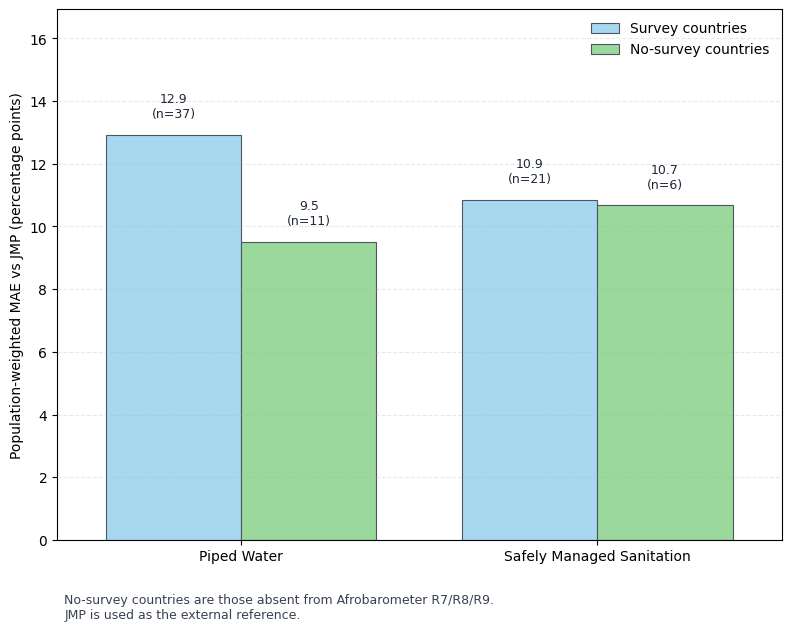

Saved: /home/mila/e/echchabo/projects/SDG6-Tracker/notebooks/no_survey_weighted_mae_vs_jmp.png


In [2]:
# No-survey performance chart (JMP reference)
import re
import unicodedata
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

survey_csv_paths = {
    'R7': Path('/home/mila/e/echchabo/scratch/SDG6-Tracker/R7.csv'),
    'R8': Path('/home/mila/e/echchabo/scratch/SDG6-Tracker/R8.csv'),
    'R9': Path('/home/mila/e/echchabo/scratch/SDG6-Tracker/R9.csv'),
}

survey_country_map = {
    'ANG': 'Angola',
    'BEN': 'Benin',
    'BFO': 'Burkina Faso',
    'BOT': 'Botswana',
    'CAM': 'Cameroon',
    'CBZ': 'Congo',
    'CDI': "Cote d'Ivoire",
    'CVE': 'Cabo Verde',
    'ESW': 'eSwatini',
    'ETH': 'Ethiopia',
    'GAB': 'Gabon',
    'GAM': 'Gambia',
    'GHA': 'Ghana',
    'GUI': 'Guinea',
    'KEN': 'Kenya',
    'LES': 'Lesotho',
    'LIB': 'Liberia',
    'MAD': 'Madagascar',
    'MAU': 'Mauritius',
    'MLI': 'Mali',
    'MLW': 'Malawi',
    'MOR': 'Morocco',
    'MOZ': 'Mozambique',
    'MTA': 'Mauritania',
    'NAM': 'Namibia',
    'NGR': 'Niger',
    'NIG': 'Nigeria',
    'SAF': 'South Africa',
    'SEN': 'Senegal',
    'SEY': 'Seychelles',
    'SRL': 'Sierra Leone',
    'STP': 'Sao Tome and Principe',
    'SUD': 'Sudan',
    'SWZ': 'eSwatini',
    'TAN': 'Tanzania',
    'TOG': 'Togo',
    'TUN': 'Tunisia',
    'UGA': 'Uganda',
    'ZAM': 'Zambia',
    'ZIM': 'Zimbabwe',
}

country_aliases = {
    "Cote d'Ivoire": "Cote d'Ivoire",
    "C\u00f4te d'Ivoire": "Cote d'Ivoire",
    'Eq. Guinea': 'Equatorial Guinea',
    'Dem. Rep. Congo': 'Democratic Republic of the Congo',
    'Central African Rep.': 'Central African Republic',
}


def canonical_country_name(name):
    if pd.isna(name):
        return name
    name = str(name).strip()
    return country_aliases.get(name, name)


def normalize_country_key(name):
    text = unicodedata.normalize('NFKD', str(name))
    text = ''.join(ch for ch in text if not unicodedata.combining(ch))
    text = text.replace('&', 'and')
    text = re.sub(r'[^a-zA-Z0-9]+', ' ', text).strip().lower()
    return text


survey_country_keys = set()
for csv_path in survey_csv_paths.values():
    df = pd.read_csv(csv_path, usecols=['RESPNO'])
    names = df['RESPNO'].astype(str).str[:3].map(survey_country_map).map(canonical_country_name)
    survey_country_keys.update(normalize_country_key(name) for name in names.dropna().unique())

summary_path = Path('/home/mila/e/echchabo/projects/SDG6-Tracker/data/inference_summary.csv')
summary = pd.read_csv(summary_path)
summary['country_key'] = summary['Country'].map(canonical_country_name).map(normalize_country_key)
summary['group'] = np.where(summary['country_key'].isin(survey_country_keys), 'Survey countries', 'No-survey countries')

specs = [
    ('Piped Water', 'Piped Water Access (%)', 'Piped (JMP)'),
    ('Safely Managed Sanitation', 'Sewage Access (%)', 'Safely managed'),
]

rows = []
country_rows = []
for service, pred_col, gt_col in specs:
    sub = summary[['Country', 'group', pred_col, gt_col, 'Total Population']].copy()
    sub[pred_col] = pd.to_numeric(sub[pred_col], errors='coerce')
    sub[gt_col] = pd.to_numeric(sub[gt_col], errors='coerce')
    sub['Total Population'] = pd.to_numeric(sub['Total Population'], errors='coerce').fillna(1.0)
    sub = sub.dropna(subset=[pred_col, gt_col])

    sub['abs_error_pp'] = (sub[pred_col] - sub[gt_col]).abs()

    for group in ['Survey countries', 'No-survey countries']:
        g = sub[sub['group'] == group]
        if g.empty:
            continue
        w = g['Total Population'].clip(lower=1.0)
        rows.append({
            'service': service,
            'group': group,
            'wmae': float(np.average(g['abs_error_pp'], weights=w)),
            'n': int(len(g)),
        })

    for _, r in sub.iterrows():
        country_rows.append({
            'service': service,
            'group': r['group'],
            'Country': r['Country'],
            'Prediction (%)': float(r[pred_col]),
            'JMP (%)': float(r[gt_col]),
            'Abs Error (pp)': float(r['abs_error_pp']),
            'Total Population': int(r['Total Population']),
        })

plot_df = pd.DataFrame(rows)
display(plot_df)

country_results = pd.DataFrame(country_rows).sort_values(
    ['service', 'group', 'Abs Error (pp)'],
    ascending=[True, True, False],
)
print('Individual country results included in the graph:')
display(country_results)

service_order = [s[0] for s in specs]
group_order = ['Survey countries', 'No-survey countries']
colors = {
    'Survey countries': '#a7d8f0',
    'No-survey countries': '#9bd89b',
}

fig, ax = plt.subplots(figsize=(7.8, 6.2), constrained_layout=True)
width = 0.22
group_spacing = 0.58
x = np.arange(len(service_order)) * group_spacing

all_vals = []
for i, group in enumerate(group_order):
    vals = []
    counts = []
    for service in service_order:
        row = plot_df[(plot_df['service'] == service) & (plot_df['group'] == group)].iloc[0]
        vals.append(float(row['wmae']))
        counts.append(int(row['n']))

    all_vals.extend(vals)
    offset = (i - 0.5) * width
    bars = ax.bar(
        x + offset,
        vals,
        width=width,
        label=group,
        color=colors[group],
        edgecolor='#4b5563',
        linewidth=0.8,
    )

    for bar, val, n in zip(bars, vals, counts):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.45,
            f'{val:.1f}\n(n={n})',
            ha='center',
            va='bottom',
            fontsize=9,
            color='#1f2937',
        )

ax.set_xticks(x)
ax.set_xticklabels(service_order)
ax.set_xlim(x.min() - 0.30, x.max() + 0.30)
ax.set_ylabel('Population-weighted MAE vs JMP (percentage points)')
# ax.set_title('Comparable Error in Countries Without Afrobarometer Survey Data')
ax.grid(axis='y', linestyle='--', alpha=0.28)
ax.legend(frameon=False, loc='upper right')

max_val = max(all_vals)
ax.set_ylim(0, max_val + 4)

ax.text(
    0.01,
    -0.1,
    'No-survey countries are those absent from Afrobarometer R7/R8/R9.\nJMP is used as the external reference.',
    transform=ax.transAxes,
    fontsize=9,
    va='top',
    color='#374151',
)

output_path = Path('/home/mila/e/echchabo/projects/SDG6-Tracker/notebooks/no_survey_weighted_mae_vs_jmp.png')
fig.savefig(output_path, dpi=300, bbox_inches='tight')
plt.show()
print(f'Saved: {output_path}')




In [4]:
country_results.to_csv('/home/mila/e/echchabo/projects/SDG6-Tracker/notebooks/no_survey_country_results.csv', index=False)